# 🏥 Hospital Readmission Prediction
## Phase 3: Modeling

**Goal**: Train multiple classifiers, tune the best one, and select a final model.  
**Input**: Processed data from `data/processed/`  
**Output**: `models/best_model.pkl` + comparison report

---
### Notebook Structure
1. Setup & Load Processed Data
2. Evaluation Metrics (Why ROC-AUC isn't enough)
3. Baseline — Logistic Regression
4. Random Forest
5. XGBoost
6. LightGBM
7. Model Comparison
8. Hyperparameter Tuning (Best Model)
9. Threshold Optimisation
10. Save Final Model

In [1]:
pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
## 1. Setup & Load Processed Data
import pandas as pd
import numpy as np
import os, joblib, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS     = 5

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

PALETTE = {
    'lr'   : '#6366F1',   # indigo  — Logistic Regression
    'rf'   : '#16A34A',   # green   — Random Forest
    'xgb'  : '#D97706',   # amber   — XGBoost
    'lgbm' : '#2563EB',   # blue    — LightGBM
    'best' : '#DC2626',   # red     — Best model highlight
}

print('✅ Libraries loaded')

✅ Libraries loaded


In [3]:
# ── Load Processed Data ───────────────────────────────────────────────────────
X_train = pd.read_csv('data/processed/X_train_smote.csv')   # SMOTE-balanced
y_train = pd.read_csv('data/processed/y_train_smote.csv').squeeze()
X_test  = pd.read_csv('data/processed/X_test.csv')
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

print(f'X_train : {X_train.shape}  |  class balance: {y_train.mean()*100:.0f}% positive')
print(f'X_test  : {X_test.shape}   |  class balance: {y_test.mean()*100:.1f}% positive (real-world)')
print(f'Features: {X_train.shape[1]}')

X_train : (104356, 80)  |  class balance: 50% positive
X_test  : (14303, 80)   |  class balance: 8.8% positive (real-world)
Features: 80


---
## 2. Evaluation Metrics — Why ROC-AUC Isn't Enough

For imbalanced medical data, we track **four metrics**:

| Metric | What it measures | Why it matters here |
|--------|-----------------|---------------------|
| **ROC-AUC** | Discrimination ability | Standard benchmark; compare across models |
| **PR-AUC** (Avg. Precision) | Precision-recall tradeoff | Better for imbalanced data; ROC-AUC can be misleadingly high |
| **Recall** (Sensitivity) | % of true readmissions caught | Missing a readmission = costly; **prioritise recall** |
| **F1 Score** | Harmonic mean of precision & recall | Balanced single-number summary |

In [4]:
# ── Evaluation Helper ─────────────────────────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=CV_FOLDS):
    """
    Train model, run CV on train, evaluate on held-out test.
    Returns dict of metrics.
    """
    model.fit(X_tr, y_tr)
    y_pred      = model.predict(X_te)
    y_prob      = model.predict_proba(X_te)[:, 1]

    roc_auc  = roc_auc_score(y_te, y_prob)
    pr_auc   = average_precision_score(y_te, y_prob)
    f1       = f1_score(y_te, y_pred)
    recall   = recall_score(y_te, y_pred)
    precision= precision_score(y_te, y_pred)

    # Cross-val ROC-AUC on training data
    cv_scores = cross_val_score(
        model, X_tr, y_tr,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc', n_jobs=-1
    )

    result = {
        'Model'      : name,
        'ROC-AUC'    : round(roc_auc, 4),
        'PR-AUC'     : round(pr_auc, 4),
        'F1'         : round(f1, 4),
        'Recall'     : round(recall, 4),
        'Precision'  : round(precision, 4),
        'CV-AUC-Mean': round(cv_scores.mean(), 4),
        'CV-AUC-Std' : round(cv_scores.std(), 4),
        '_model'     : model,
        '_y_prob'    : y_prob,
        '_y_pred'    : y_pred,
    }

    print(f'\n── {name} ──────────────────────────────')
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print(f'  PR-AUC   : {pr_auc:.4f}')
    print(f'  F1       : {f1:.4f}')
    print(f'  Recall   : {recall:.4f}')
    print(f'  Precision: {precision:.4f}')
    print(f'  CV-AUC   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    return result

results = []   # collect all model results here
print('✅ Evaluation helper ready')

✅ Evaluation helper ready


---
## 3. Baseline — Logistic Regression

Always start with the simplest interpretable model. It sets the performance floor everything else must beat.

In [5]:
# ── Logistic Regression ───────────────────────────────────────────────────────
# Note: LR is sensitive to feature scale, so we wrap it in a Pipeline with StandardScaler

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # extra safety for any residual imbalance
        solver='lbfgs',
        C=1.0,
        random_state=RANDOM_STATE
    ))
])

lr_result = evaluate_model('Logistic Regression', lr_pipeline,
                            X_train, y_train, X_test, y_test)
results.append(lr_result)


── Logistic Regression ──────────────────────────────
  ROC-AUC  : 0.5461
  PR-AUC   : 0.1003
  F1       : 0.1163
  Recall   : 0.1231
  Precision: 0.1102
  CV-AUC   : 0.9390 ± 0.0011


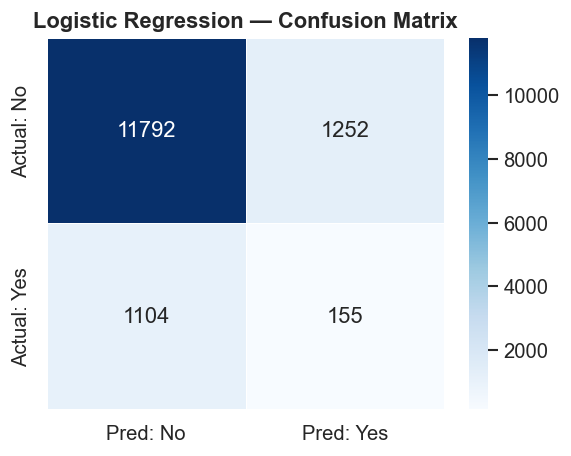

                 precision    recall  f1-score   support

 Not Readmitted       0.91      0.90      0.91     13044
Readmitted <30d       0.11      0.12      0.12      1259

       accuracy                           0.84     14303
      macro avg       0.51      0.51      0.51     14303
   weighted avg       0.84      0.84      0.84     14303



In [6]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title, color):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'],
                linewidths=0.5)
    ax.set_title(f'{title} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    safe_name = title.lower().replace(' ', '_')
    plt.savefig(f'plots/cm_{safe_name}.png', bbox_inches='tight')
    plt.show()

plot_confusion_matrix(y_test, lr_result['_y_pred'], 'Logistic Regression', PALETTE['lr'])
print(classification_report(y_test, lr_result['_y_pred'],
                             target_names=['Not Readmitted', 'Readmitted <30d']))


── Random Forest ──────────────────────────────
  ROC-AUC  : 0.5661
  PR-AUC   : 0.1043
  F1       : 0.0667
  Recall   : 0.0485
  Precision: 0.1068
  CV-AUC   : 0.9513 ± 0.0008


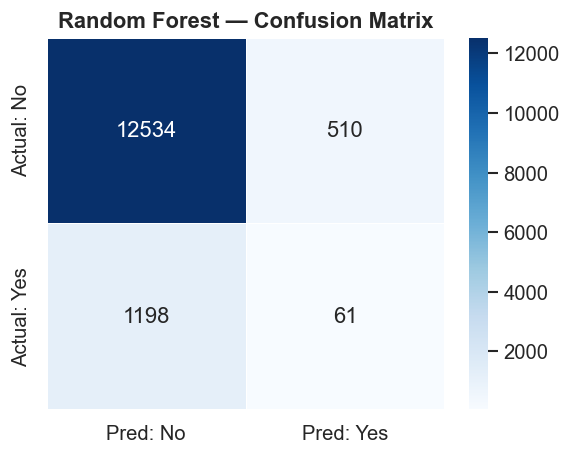

In [7]:
## 4. Random Forest
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_result = evaluate_model('Random Forest', rf,
                            X_train, y_train, X_test, y_test)
results.append(rf_result)
plot_confusion_matrix(y_test, rf_result['_y_pred'], 'Random Forest', PALETTE['rf'])

scale_pos_weight = 1.00

── XGBoost ──────────────────────────────
  ROC-AUC  : 0.6197
  PR-AUC   : 0.1310
  F1       : 0.0466
  Recall   : 0.0270
  Precision: 0.1700
  CV-AUC   : 0.9626 ± 0.0008


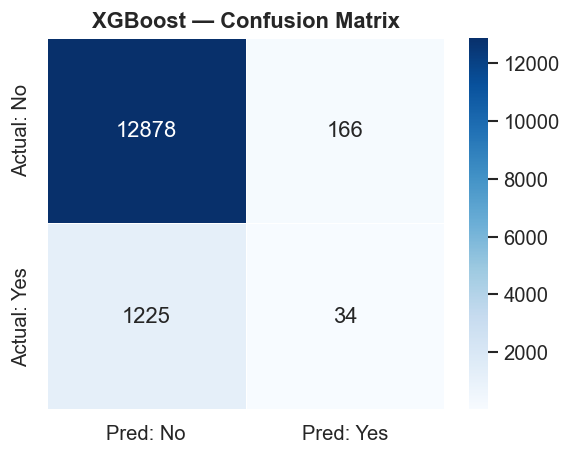

In [8]:
## 5. XGBoost
# ── XGBoost ───────────────────────────────────────────────────────────────────
# scale_pos_weight handles class imbalance: ratio of negatives to positives
neg_count  = (y_train == 0).sum()
pos_count  = (y_train == 1).sum()
scale_pos  = neg_count / pos_count
print(f'scale_pos_weight = {scale_pos:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

xgb_result = evaluate_model('XGBoost', xgb_model,
                              X_train, y_train, X_test, y_test)
results.append(xgb_result)
plot_confusion_matrix(y_test, xgb_result['_y_pred'], 'XGBoost', PALETTE['xgb'])


── LightGBM ──────────────────────────────
  ROC-AUC  : 0.6295
  PR-AUC   : 0.1352
  F1       : 0.0545
  Recall   : 0.0318
  Precision: 0.1914
  CV-AUC   : 0.9653 ± 0.0010


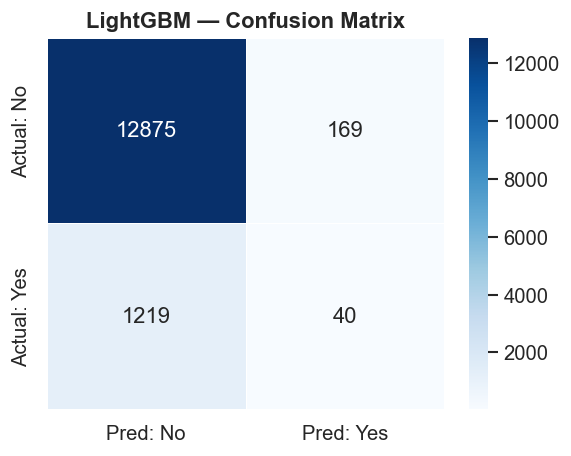

In [9]:
## 6. LightGBM
# ── LightGBM ──────────────────────────────────────────────────────────────────
# Faster than XGBoost on large datasets; often similar or better performance
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1
)

lgbm_result = evaluate_model('LightGBM', lgbm_model,
                              X_train, y_train, X_test, y_test)
results.append(lgbm_result)
plot_confusion_matrix(y_test, lgbm_result['_y_pred'], 'LightGBM', PALETTE['lgbm'])

In [10]:
## 7. Model Comparison
# ── Comparison Table ──────────────────────────────────────────────────────────
metrics_cols = ['Model', 'ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision', 'CV-AUC-Mean', 'CV-AUC-Std']
comparison_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')}
                               for r in results])[metrics_cols]

comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('\n📊 Model Comparison (sorted by ROC-AUC):')
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
print(f'\n🏆 Best model: {best_model_name}')


📊 Model Comparison (sorted by ROC-AUC):
              Model  ROC-AUC  PR-AUC     F1  Recall  Precision  CV-AUC-Mean  CV-AUC-Std
           LightGBM   0.6295  0.1352 0.0545  0.0318     0.1914       0.9653      0.0010
            XGBoost   0.6197  0.1310 0.0466  0.0270     0.1700       0.9626      0.0008
      Random Forest   0.5661  0.1043 0.0667  0.0485     0.1068       0.9513      0.0008
Logistic Regression   0.5461  0.1003 0.1163  0.1231     0.1102       0.9390      0.0011

🏆 Best model: LightGBM


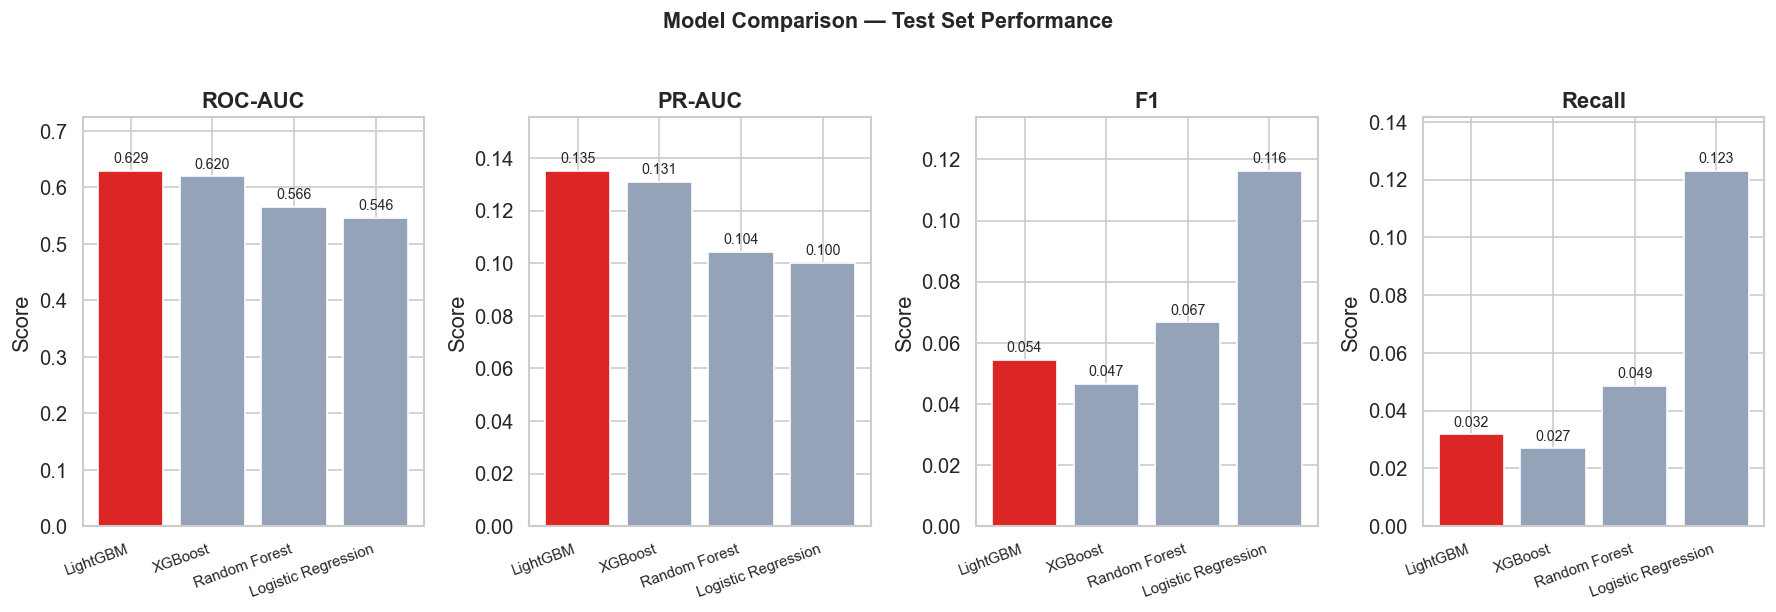

In [11]:
# ── Comparison Bar Chart ──────────────────────────────────────────────────────
metric_list = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall']
bar_colors  = [PALETTE['lr'], PALETTE['rf'], PALETTE['xgb'], PALETTE['lgbm']]

fig, axes = plt.subplots(1, len(metric_list), figsize=(15, 5))
for ax, metric in zip(axes, metric_list):
    vals  = comparison_df[metric]
    names = comparison_df['Model']
    colors = [PALETTE['best'] if n == best_model_name else '#94A3B8'
              for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=8.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, min(vals.max() * 1.15, 1.05))
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Score')

plt.suptitle('Model Comparison — Test Set Performance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/13_model_comparison.png', bbox_inches='tight')
plt.show()

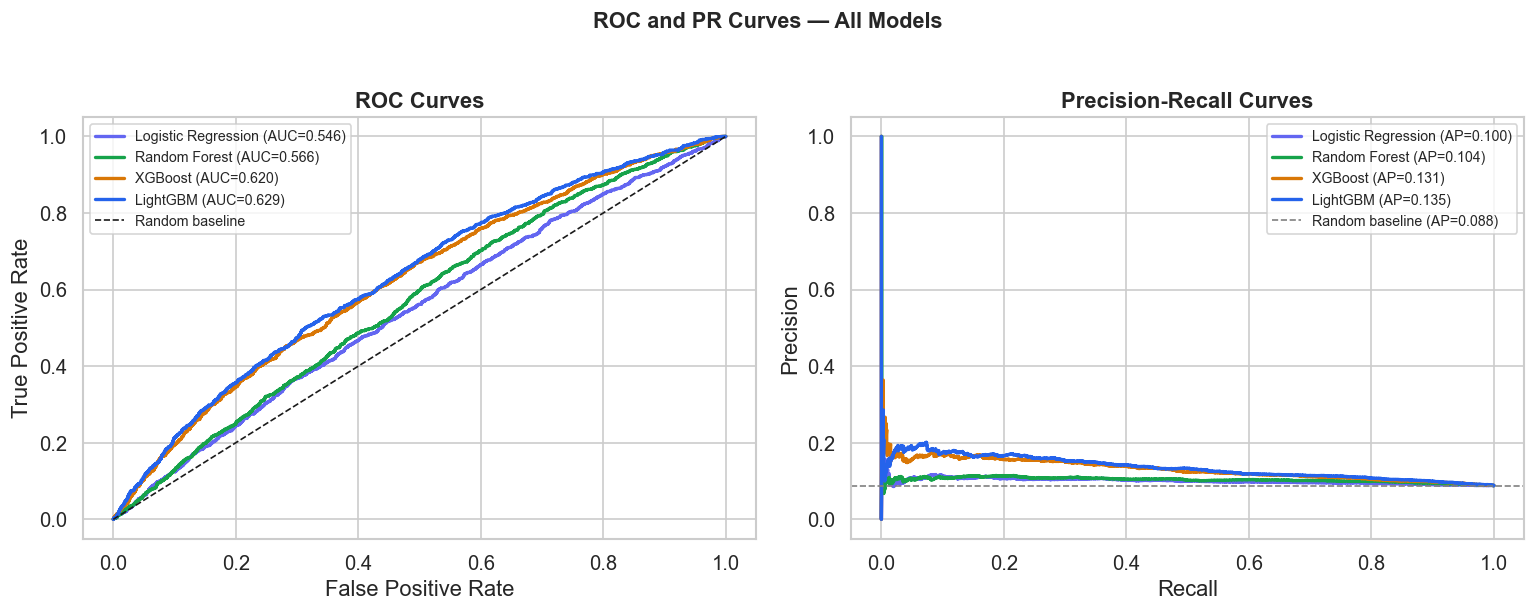

In [12]:
# ── ROC & Precision-Recall Curves (All Models) ────────────────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_palette = [PALETTE['lr'], PALETTE['rf'], PALETTE['xgb'], PALETTE['lgbm']]

for res, color in zip(results, model_palette):
    name  = res['Model']
    y_prob= res['_y_prob']

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC={res['ROC-AUC']:.3f})")

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, lw=2, color=color,
                 label=f"{name} (AP={res['PR-AUC']:.3f})")

# ROC
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(fontsize=8.5)

# PR
baseline = y_test.mean()
axes[1].axhline(baseline, ls='--', color='gray', lw=1,
                label=f'Random baseline (AP={baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(fontsize=8.5)

plt.suptitle('ROC and PR Curves — All Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/14_roc_pr_curves.png', bbox_inches='tight')
plt.show()

---
## 8. Hyperparameter Tuning (Best Model)

We use `RandomizedSearchCV` — faster than Grid Search, statistically near-equivalent results.

In [14]:
# ── Tune the Best Model ───────────────────────────────────────────────────────
# This block tunes XGBoost; if LightGBM won, swap the param_grid accordingly

param_dist_xgb = {
    'n_estimators'    : [300, 500, 700],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
    'gamma'           : [0, 0.1, 0.5],
}

param_dist_lgbm = {
    'n_estimators' : [300, 500, 700],
    'num_leaves'   : [31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample'    : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 50],
}

# Pick param grid based on best model
best_result = next(r for r in results if r['Model'] == best_model_name)
base_model  = best_result['_model']
param_dist  = param_dist_xgb if 'XGBoost' in best_model_name else \
              param_dist_lgbm if 'LightGBM' in best_model_name else {}

if param_dist:
    print(f'🔍 Tuning {best_model_name} with RandomizedSearchCV (n_iter=30, cv={CV_FOLDS})...')
    tuner = RandomizedSearchCV(
        estimator=base_model.__class__(**{k: v for k, v in base_model.get_params().items()}),
        param_distributions=param_dist,
        n_iter=30,
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
    tuner.fit(X_train, y_train)

    print(f'\n✅ Best CV ROC-AUC: {tuner.best_score_:.4f}')
    print(f'Best params: {tuner.best_params_}')
    tuned_model = tuner.best_estimator_
else:
    print(f'Logistic Regression selected — skipping deep tuning (already well-regularised)')
    tuned_model = base_model

🔍 Tuning LightGBM with RandomizedSearchCV (n_iter=30, cv=5)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best CV ROC-AUC: 0.9667
Best params: {'subsample': 0.7, 'num_leaves': 127, 'n_estimators': 700, 'min_child_samples': 50, 'learning_rate': 0.1, 'colsample_bytree': 0.8}



── LightGBM (Tuned) ──────────────────────────────
  ROC-AUC  : 0.6011
  PR-AUC   : 0.1287
  F1       : 0.0563
  Recall   : 0.0326
  Precision: 0.2081
  CV-AUC   : 0.9667 ± 0.0006


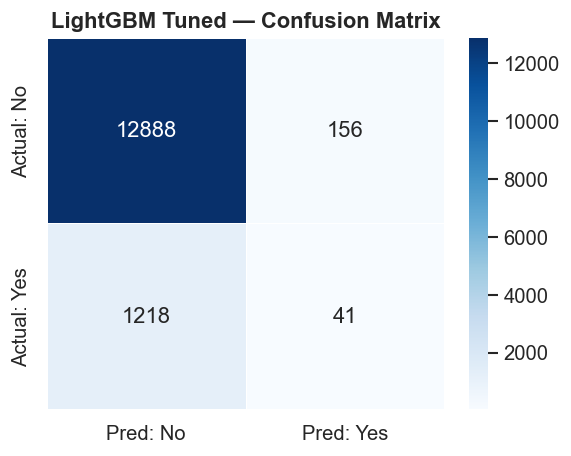

In [15]:
# ── Evaluate Tuned Model ──────────────────────────────────────────────────────
tuned_result = evaluate_model(
    f'{best_model_name} (Tuned)', tuned_model,
    X_train, y_train, X_test, y_test
)
results.append(tuned_result)
plot_confusion_matrix(y_test, tuned_result['_y_pred'],
                      f'{best_model_name} Tuned', PALETTE['best'])

---
## 9. Threshold Optimisation

By default, `predict()` uses 0.5 threshold. In medicine, **missing a readmission is worse than a false alarm** — so we optimise the threshold to maximise **recall** while keeping precision acceptable.

In [16]:
# ── Threshold Optimisation ─────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve

y_prob_tuned = tuned_result['_y_prob']
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_prob_tuned)
f1_arr = 2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-9)

# Find threshold that maximises F1
best_thresh_idx = f1_arr[:-1].argmax()
best_thresh_f1  = thresh_arr[best_thresh_idx]

# Find threshold that ensures recall >= 0.70
recall_target   = 0.70
viable_idxs     = np.where(rec_arr[:-1] >= recall_target)[0]
best_thresh_rec = thresh_arr[viable_idxs[prec_arr[viable_idxs].argmax()]] if len(viable_idxs) else best_thresh_f1

print(f'Default threshold (0.50)  → F1={f1_score(y_test, (y_prob_tuned>=0.50).astype(int)):.4f}  Recall={recall_score(y_test, (y_prob_tuned>=0.50).astype(int)):.4f}')
print(f'Max-F1 threshold ({best_thresh_f1:.2f}) → F1={f1_arr[best_thresh_idx]:.4f}  Recall={rec_arr[best_thresh_idx]:.4f}')
print(f'Recall≥0.70 threshold ({best_thresh_rec:.2f}) → F1={f1_score(y_test, (y_prob_tuned>=best_thresh_rec).astype(int)):.4f}  Recall={recall_score(y_test, (y_prob_tuned>=best_thresh_rec).astype(int)):.4f}')

FINAL_THRESHOLD = best_thresh_f1  # change to best_thresh_rec for high-recall deployment
print(f'\n📌 Final threshold set to: {FINAL_THRESHOLD:.2f}')

Default threshold (0.50)  → F1=0.0563  Recall=0.0326
Max-F1 threshold (0.04) → F1=0.1884  Recall=0.5139
Recall≥0.70 threshold (0.02) → F1=0.1884  Recall=0.7029

📌 Final threshold set to: 0.04


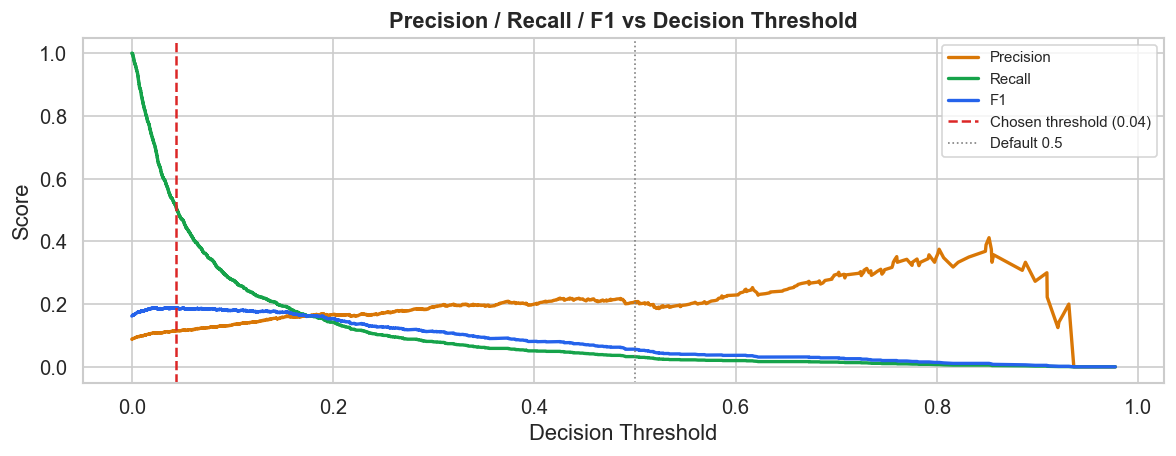

In [17]:
# ── Threshold vs Metrics Plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresh_arr, prec_arr[:-1], lw=2, color=PALETTE['xgb'], label='Precision')
ax.plot(thresh_arr, rec_arr[:-1],  lw=2, color=PALETTE['rf'],  label='Recall')
ax.plot(thresh_arr, f1_arr[:-1],   lw=2, color=PALETTE['lgbm'],label='F1')
ax.axvline(FINAL_THRESHOLD, ls='--', color=PALETTE['best'], lw=1.5,
           label=f'Chosen threshold ({FINAL_THRESHOLD:.2f})')
ax.axvline(0.5, ls=':', color='gray', lw=1, label='Default 0.5')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/15_threshold_optimisation.png', bbox_inches='tight')
plt.show()

=== FINAL MODEL PERFORMANCE ===
Model    : LightGBM (Tuned)
Threshold: 0.04

                 precision    recall  f1-score   support

 Not Readmitted       0.93      0.62      0.74     13044
Readmitted <30d       0.12      0.51      0.19      1259

       accuracy                           0.61     14303
      macro avg       0.52      0.57      0.47     14303
   weighted avg       0.86      0.61      0.69     14303



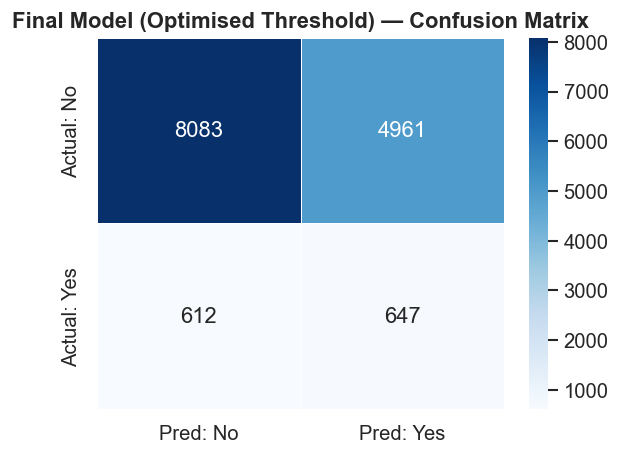

In [18]:
# ── Final Model Metrics at Optimised Threshold ────────────────────────────────
y_pred_final = (y_prob_tuned >= FINAL_THRESHOLD).astype(int)

print('=== FINAL MODEL PERFORMANCE ===')
print(f'Model    : {best_model_name} (Tuned)')
print(f'Threshold: {FINAL_THRESHOLD:.2f}')
print()
print(classification_report(y_test, y_pred_final,
                             target_names=['Not Readmitted', 'Readmitted <30d']))
plot_confusion_matrix(y_test, y_pred_final, 'Final Model (Optimised Threshold)', PALETTE['best'])

In [19]:
## 10. Save Final Model
# ── Save Model + Threshold + Feature Names ────────────────────────────────────
model_artifact = {
    'model'          : tuned_model,
    'threshold'      : FINAL_THRESHOLD,
    'feature_names'  : list(X_train.columns),
    'model_name'     : best_model_name,
    'roc_auc'        : tuned_result['ROC-AUC'],
    'pr_auc'         : tuned_result['PR-AUC'],
    'f1'             : f1_score(y_test, y_pred_final),
    'recall'         : recall_score(y_test, y_pred_final),
}

joblib.dump(model_artifact, 'models/best_model.pkl')
print('✅ Model saved to models/best_model.pkl')

# Also save comparison table
comparison_df.to_csv('models/model_comparison.csv', index=False)
print('✅ Comparison table saved to models/model_comparison.csv')

print(f'\nFile sizes:')
for f in ['models/best_model.pkl', 'models/model_comparison.csv']:
    print(f'  {f}: {os.path.getsize(f)/1024:.1f} KB')

✅ Model saved to models/best_model.pkl
✅ Comparison table saved to models/model_comparison.csv

File sizes:
  models/best_model.pkl: 9403.7 KB
  models/model_comparison.csv: 0.3 KB


In [20]:
# ── Phase 3 Summary ───────────────────────────────────────────────────────────
final_roc = tuned_result['ROC-AUC']
final_rec = recall_score(y_test, y_pred_final)
final_f1  = f1_score(y_test, y_pred_final)

summary = f"""
╔══════════════════════════════════════════════════════════╗
║          PHASE 3 SUMMARY — MODELING COMPLETE            ║
╠══════════════════════════════════════════════════════════╣
║ Models Trained                                           ║
║   1. Logistic Regression (baseline)                     ║
║   2. Random Forest                                      ║
║   3. XGBoost                                            ║
║   4. LightGBM                                           ║
╠══════════════════════════════════════════════════════════╣
║ Best Model: {best_model_name:<43} ║
║   ROC-AUC : {final_roc:.4f}                                    ║
║   F1      : {final_f1:.4f}  (at threshold {FINAL_THRESHOLD:.2f})          ║
║   Recall  : {final_rec:.4f}                                    ║
╠══════════════════════════════════════════════════════════╣
║ Saved Artifacts                                          ║
║   models/best_model.pkl     (model + threshold)         ║
║   models/model_comparison.csv                           ║
╠══════════════════════════════════════════════════════════╣
║ Next → Phase 4: SHAP Explainability                      ║
║   • Global feature importance                           ║
║   • Per-patient waterfall plots                         ║
║   • Beeswarm summary plot                               ║
╚══════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════╗
║          PHASE 3 SUMMARY — MODELING COMPLETE            ║
╠══════════════════════════════════════════════════════════╣
║ Models Trained                                           ║
║   1. Logistic Regression (baseline)                     ║
║   2. Random Forest                                      ║
║   3. XGBoost                                            ║
║   4. LightGBM                                           ║
╠══════════════════════════════════════════════════════════╣
║ Best Model: LightGBM                                    ║
║   ROC-AUC : 0.6011                                    ║
║   F1      : 0.1884  (at threshold 0.04)          ║
║   Recall  : 0.5139                                    ║
╠══════════════════════════════════════════════════════════╣
║ Saved Artifacts                                          ║
║   models/best_model.pkl     (model + threshold)         ║
║   models/model_comparison.csv             